# Mutual Fund Selection Strategy — Scoring Model

A systematic, data-driven approach to rank 68 funds across five factors:

| # | Factor | Approach |
|---|--------|----------|
| 1 | **10-Year Return** | Percentile score within universe (missing = adjusted weight) |
| 2 | **5-Year Return** | Percentile score within universe (missing = adjusted weight) |
| 3 | **Stability / Consistency** | Inverse-CV percentile over available long-horizon returns |
| 4 | **Category** | Used for grouping & top-pick-per-category; not a raw score |
| 5 | **Crisil Rating** | Used as a confidence multiplier on the final score |

### Weight scheme (handles missing data gracefully)

| Data available | 10Y wt | 5Y wt | Stability wt |
|---|---|---|---|
| 10Y + 5Y + 3Y | **40%** | **35%** | **25%** |
| 5Y + 3Y (no 10Y) | — | **55%** | **45%** |
| 3Y only (no 5Y, no 10Y) | — | — | **60%** † |

† 3Y return score replaces 5Y in this edge case.

## 1. Setup & Data Loading

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

# ── aesthetics ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 130,
    "figure.facecolor": "#0d1117",
    "axes.facecolor": "#0d1117",
    "axes.edgecolor": "#30363d",
    "axes.labelcolor": "#c9d1d9",
    "text.color": "#c9d1d9",
    "xtick.color": "#c9d1d9",
    "ytick.color": "#c9d1d9",
    "grid.color": "#21262d",
    "legend.facecolor": "#161b22",
    "legend.edgecolor": "#30363d",
})

PALETTE = [
    "#58a6ff","#3fb950","#f78166","#d2a8ff","#ffa657",
    "#79c0ff","#56d364","#ff7b72","#bc8cff","#e3b341",
    "#1f6feb","#238636",
]

# ── load data ─────────────────────────────────────────────────────────────────
EXCEL = Path("../mutualfunds/Historical Returns - Mutual fund screener Mutual Fund Screening and Analysis Tool - Moneycontrol.com.xlsx")
raw = pd.read_excel(EXCEL, header=None, skiprows=1)
raw.columns = raw.iloc[0].tolist()
df = raw.iloc[1:].reset_index(drop=True).copy()

RETURN_COLS = ["1W", "1M", "3M", "6M", "YTD", "1Y", "2Y", "3Y", "5Y", "10Y"]
df[RETURN_COLS]   = df[RETURN_COLS].apply(pd.to_numeric, errors="coerce")
df["AuM (Cr)"]    = pd.to_numeric(df["AuM (Cr)"], errors="coerce")
df["Crisil Rating"] = pd.to_numeric(df["Crisil Rating"], errors="coerce")

df["Short Name"] = (
    df["Scheme Name"]
    .str.replace(r" - Direct Plan.*", "", regex=True)
    .str.replace(r" - Growth.*", "", regex=True)
    .str.strip()
)

# convert returns to %
for c in ["1Y", "3Y", "5Y", "10Y"]:
    df[c] = df[c] * 100

print(f"Total funds  : {len(df)}")
print(f"Have 10Y data: {df['10Y'].notna().sum()}")
print(f"Have 5Y data : {df['5Y'].notna().sum()}")
print(f"Have 3Y data : {df['3Y'].notna().sum()}")   # all 68

Total funds  : 68
Have 10Y data: 46
Have 5Y data : 57
Have 3Y data : 68


## 2. Factor Scoring

Each factor is converted to a **0–100 percentile score** so they are on a comparable scale.

### Helper: percentile scorer

```
score = rank(value, ascending) / n × 100
```

Higher score always = better for investment.

In [2]:
def pct_score(series: pd.Series, ascending: bool = True) -> pd.Series:
    """Return 0-100 percentile score; NaN inputs stay NaN."""
    return series.rank(pct=True, ascending=ascending, na_option="keep") * 100


scores = df[["Short Name", "Category Name", "Crisil Rating", "AuM (Cr)",
             "1Y", "3Y", "5Y", "10Y"]].copy()

# ── Factor 1: 10-Year Return ─────────────────────────────────────────────────
scores["score_10Y"] = pct_score(scores["10Y"])

# ── Factor 2: 5-Year Return ──────────────────────────────────────────────────
scores["score_5Y"]  = pct_score(scores["5Y"])

# ── Factor 3: Stability (inverse CV) ─────────────────────────────────────────
# Compute CV over whichever long-horizon columns exist per fund
# At minimum every fund has 1Y and 3Y (we use all available)
STAB_COLS = ["1Y", "3Y", "5Y", "10Y"]
ret_matrix = scores[STAB_COLS]

scores["_mean"]  = ret_matrix.mean(axis=1)
scores["_std"]   = ret_matrix.std(axis=1)
scores["CV"]     = (scores["_std"] / scores["_mean"].abs()) * 100

# Funds where all returns are in same direction (all positive) → reasonable CV
# Low CV = stable → ascending=False so top scorer = most stable
scores["score_stability"] = pct_score(scores["CV"], ascending=False)

scores.drop(columns=["_mean", "_std"], inplace=True)

# ── summary table ─────────────────────────────────────────────────────────────
summary = scores[["Short Name", "Category Name", "Crisil Rating",
                  "10Y", "5Y", "3Y", "CV",
                  "score_10Y", "score_5Y", "score_stability"]]
print("Individual factor scores computed ✓")
print(f"\n10Y score  — non-null: {scores['score_10Y'].notna().sum()},  null: {scores['score_10Y'].isna().sum()}")
print(f"5Y score   — non-null: {scores['score_5Y'].notna().sum()},  null: {scores['score_5Y'].isna().sum()}")
print(f"Stability  — non-null: {scores['score_stability'].notna().sum()},  null: {scores['score_stability'].isna().sum()}")
summary.round(1).head(10)

Individual factor scores computed ✓

10Y score  — non-null: 46,  null: 22
5Y score   — non-null: 57,  null: 11
Stability  — non-null: 68,  null: 0


,Short Name,Category Name,Crisil Rating,10Y,5Y,3Y,CV,score_10Y,score_5Y,score_stability
0,DSP Natural Resources and New Energy Fund,Sectoral/Thematic,5,21.0,21.7,24.6,20.7,100.0,93.0,60.3
1,Edelweiss Mid Cap Fund,Mid Cap Fund,5,20.4,21.3,25.5,14.2,97.8,89.5,88.2
2,Bank of India Manufacturing & Infrastructure Fund,Sectoral/Thematic,5,20.0,22.3,25.4,9.9,95.7,94.7,95.6
3,HDFC Mid Cap Fund,Mid Cap Fund,4,19.6,21.4,24.2,14.4,93.5,91.2,86.8
4,Mirae Asset ELSS Tax Saver Fund,ELSS,4,18.8,13.6,16.3,22.5,91.3,22.8,51.5
5,Parag Parikh Flexi Cap Fund,Flexi Cap Fund,5,18.6,17.6,19.5,35.7,89.1,57.9,23.5
6,LIC MF Infrastructure Fund,Sectoral/Thematic,4,18.5,23.9,28.5,20.2,87.0,98.2,64.7
7,Canara Robeco Infrastructure,Sectoral/Thematic,4,18.3,24.0,26.6,17.4,84.8,100.0,75.0
8,ICICI Prudential MidCap Fund,Mid Cap Fund,4,18.2,19.8,25.1,17.1,82.6,84.2,76.5
9,Kotak Contra Fund,Contra Fund,4,18.0,17.0,20.2,15.8,80.4,52.6,79.4


### 2.1 Visualise Individual Factor Distributions

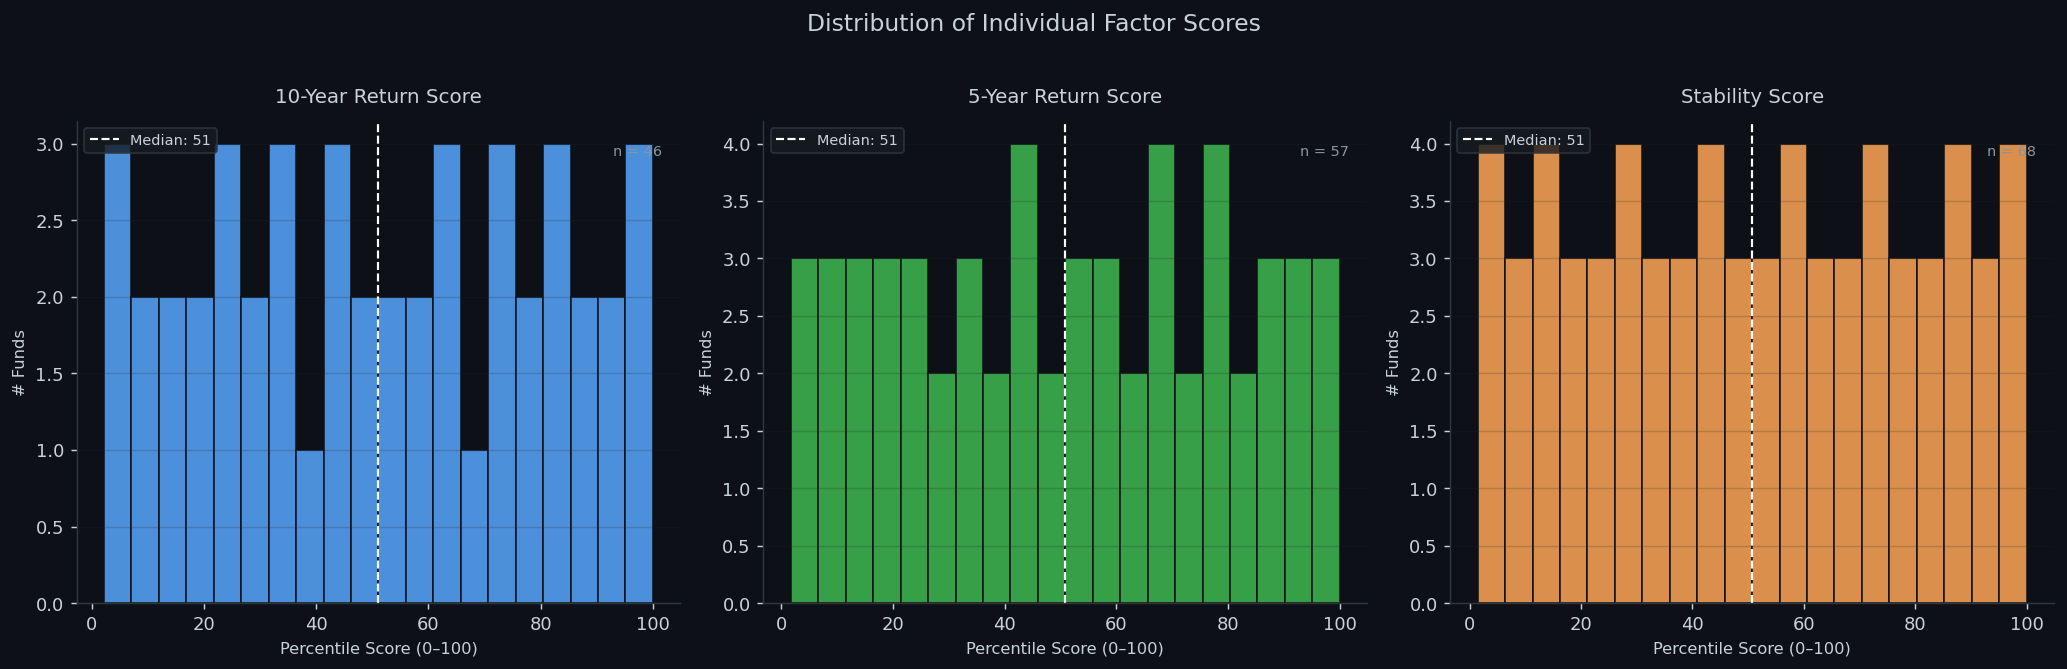

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

factor_meta = [
    ("score_10Y",      "10-Year Return Score", "#58a6ff"),
    ("score_5Y",       "5-Year Return Score",  "#3fb950"),
    ("score_stability","Stability Score",       "#ffa657"),
]

for ax, (col, title, color) in zip(axes, factor_meta):
    data = scores[col].dropna()
    ax.hist(data, bins=20, color=color, alpha=0.85, edgecolor="#0d1117")
    ax.axvline(data.median(), color="white", linewidth=1.2, linestyle="--",
               label=f"Median: {data.median():.0f}")
    ax.set_title(title, fontsize=11, pad=10)
    ax.set_xlabel("Percentile Score (0–100)", fontsize=9)
    ax.set_ylabel("# Funds", fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.2)
    for spine in ["top", "right"]: ax.spines[spine].set_visible(False)
    # annotate n
    ax.text(0.97, 0.95, f"n = {len(data)}", transform=ax.transAxes,
            ha="right", va="top", fontsize=8, color="#8b949e")

plt.suptitle("Distribution of Individual Factor Scores", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 3. Composite Score

### Weighting Logic

Funds are grouped by data completeness and scored accordingly:

| Tier | Condition | Weights |
|------|-----------|---------|
| **A** — Full history | Has 10Y + 5Y | 40% 10Y + 35% 5Y + 25% Stability |
| **B** — Partial (no 10Y) | Has 5Y, no 10Y | 55% 5Y + 45% Stability |
| **C** — New fund | No 5Y + no 10Y | 60% 3Y + 40% Stability |

### Crisil Rating Multiplier

A 5-star fund gets a **+5% boost**; a 4-star fund gets **no penalty but no bonus**.  
This reflects peer-relative risk-adjusted quality without over-weighting the rating.

$$\text{Final Score} = \text{Composite Score} \times \left(1 + \frac{\text{Rating} - 4}{20}\right)$$

In [4]:
sc = scores.copy()

# ── 3Y score — needed for Tier C ─────────────────────────────────────────────
sc["score_3Y"] = pct_score(sc["3Y"])

# ── assign data tier ──────────────────────────────────────────────────────────
def assign_tier(row):
    if pd.notna(row["10Y"]) and pd.notna(row["5Y"]):
        return "A"   # full history
    elif pd.notna(row["5Y"]):
        return "B"   # 5Y available, 10Y missing
    else:
        return "C"   # only 3Y (newest funds)

sc["data_tier"] = sc.apply(assign_tier, axis=1)

# ── composite score by tier ───────────────────────────────────────────────────
def composite(row):
    t = row["data_tier"]
    if t == "A":
        return 0.40 * row["score_10Y"] + 0.35 * row["score_5Y"] + 0.25 * row["score_stability"]
    elif t == "B":
        return 0.55 * row["score_5Y"] + 0.45 * row["score_stability"]
    else:   # C
        return 0.60 * row["score_3Y"] + 0.40 * row["score_stability"]

sc["composite_score"] = sc.apply(composite, axis=1)

# ── Crisil rating multiplier  (5★ → ×1.05, 4★ → ×1.00) ──────────────────────
sc["rating_mult"] = 1 + (sc["Crisil Rating"] - 4) / 20
sc["final_score"]  = (sc["composite_score"] * sc["rating_mult"]).round(2)

# ── overall rank ──────────────────────────────────────────────────────────────
sc["rank"] = sc["final_score"].rank(ascending=False, method="min").astype(int)
sc = sc.sort_values("rank").reset_index(drop=True)

tier_counts = sc["data_tier"].value_counts().sort_index()
print("Data tiers:")
for t, n in tier_counts.items():
    label = {"A": "Full (10Y+5Y)", "B": "Partial (5Y only)", "C": "New (3Y only)"}[t]
    print(f"  Tier {t} — {label}: {n} funds")

print(f"\nFinal score range: {sc['final_score'].min():.1f} – {sc['final_score'].max():.1f}")
print(f"5-star funds avg final score : {sc[sc['Crisil Rating']==5]['final_score'].mean():.1f}")
print(f"4-star funds avg final score : {sc[sc['Crisil Rating']==4]['final_score'].mean():.1f}")

Data tiers:
  Tier A — Full (10Y+5Y): 46 funds
  Tier B — Partial (5Y only): 11 funds
  Tier C — New (3Y only): 11 funds

Final score range: 3.8 – 100.1
5-star funds avg final score : 58.7
4-star funds avg final score : 47.1


## 4. Full Ranked Leaderboard

In [5]:
TIER_LABEL = {"A": "Full (10Y+5Y)", "B": "Partial (5Y)", "C": "New (3Y)"}

display = sc[[
    "rank", "Short Name", "Category Name", "Crisil Rating", "data_tier",
    "10Y", "5Y", "CV",
    "score_10Y", "score_5Y", "score_stability",
    "composite_score", "final_score"
]].copy()

display["data_tier"]   = display["data_tier"].map(TIER_LABEL)
display["Crisil Rating"] = display["Crisil Rating"].astype(int).apply(lambda r: "★" * r)

for c in ["10Y", "5Y", "CV"]:
    display[c] = display[c].apply(lambda x: f"{x:.1f}%" if pd.notna(x) else "—")
for c in ["score_10Y", "score_5Y", "score_stability", "composite_score"]:
    display[c] = display[c].apply(lambda x: f"{x:.0f}" if pd.notna(x) else "—")

display = display.rename(columns={
    "rank": "Rank",
    "Short Name": "Fund",
    "Category Name": "Category",
    "Crisil Rating": "Rating",
    "data_tier": "Data",
    "score_10Y": "S:10Y",
    "score_5Y": "S:5Y",
    "score_stability": "S:Stability",
    "composite_score": "Composite",
    "final_score": "Final ★",
})
display.set_index("Rank", inplace=True)
display

,Fund,Category,Rating,Data,10Y,5Y,CV,S:10Y,S:5Y,S:Stability,Composite,Final ★
Rank,,,,,,,,,,,,
1,Bank of India Manufacturing & Infrastructure Fund,Sectoral/Thematic,★★★★★,Full (10Y+5Y),20.0%,22.3%,9.9%,96,95,96,95,100.08
2,Edelweiss Mid Cap Fund,Mid Cap Fund,★★★★★,Full (10Y+5Y),20.4%,21.3%,14.2%,98,89,88,93,97.13
3,DSP Natural Resources and New Energy Fund,Sectoral/Thematic,★★★★★,Full (10Y+5Y),21.0%,21.7%,20.7%,100,93,60,88,92.00
4,HDFC Mid Cap Fund,Mid Cap Fund,★★★★,Full (10Y+5Y),19.6%,21.4%,14.4%,93,91,87,91,91.01
5,Canara Robeco Infrastructure,Sectoral/Thematic,★★★★,Full (10Y+5Y),18.3%,24.0%,17.4%,85,100,75,88,87.66
...,...,...,...,...,...,...,...,...,...,...,...,...
64,ITI ELSS Tax Saver Fund,ELSS,★★★★,Partial (5Y),—,12.9%,40.4%,—,14,13,14,13.68
65,Canara Robeco Focused Fund,Focused Fund,★★★★,New (3Y),—,—,46.5%,—,—,6,13,12.94
66,Aditya Birla Sun Life Large Cap Fund,Large Cap Fund,★★★★,Full (10Y+5Y),13.4%,12.1%,30.5%,4,4,34,11,11.42


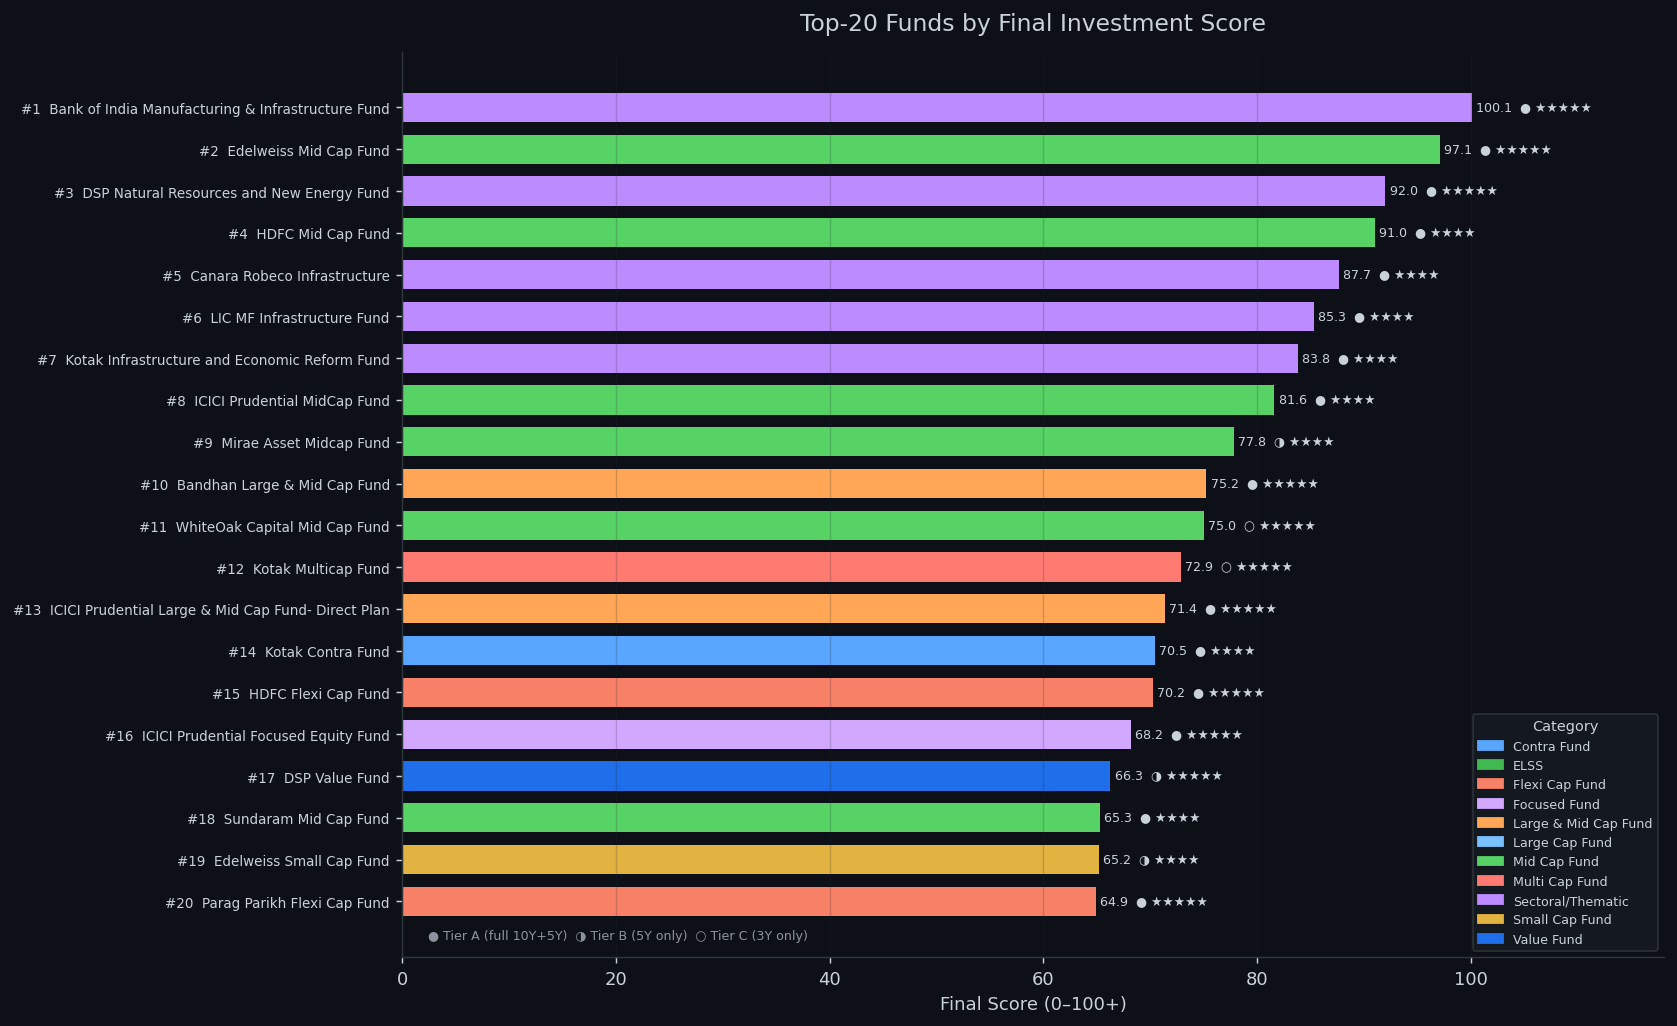

In [6]:
# ── Visual: Top-20 final score horizontal bar ────────────────────────────────
top20 = sc.head(20).copy()
cat_list = sorted(sc["Category Name"].unique())
cat_colors = {c: PALETTE[i % len(PALETTE)] for i, c in enumerate(cat_list)}
bar_colors = [cat_colors[c] for c in top20["Category Name"]]

fig, ax = plt.subplots(figsize=(13, 8))
bars = ax.barh(
    range(len(top20)), top20["final_score"].values[::-1],
    color=bar_colors[::-1], height=0.7
)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(
    [f"#{r}  {n}" for r, n in zip(
        top20["rank"].values[::-1],
        top20["Short Name"].values[::-1]
    )],
    fontsize=7.5
)

# annotate score + tier
for i, (_, row) in enumerate(top20.iloc[::-1].iterrows()):
    tier_badge = {"A": "●", "B": "◑", "C": "○"}[row["data_tier"]]
    stars = "★" * int(row["Crisil Rating"])
    ax.text(
        row["final_score"] + 0.4, i,
        f"{row['final_score']:.1f}  {tier_badge} {stars}",
        va="center", fontsize=7, color="#c9d1d9"
    )

# category legend
handles = [mpatches.Patch(color=v, label=k) for k, v in cat_colors.items()]
ax.legend(handles=handles, title="Category", fontsize=7, title_fontsize=8,
          loc="lower right")

ax.set_xlabel("Final Score (0–100+)", fontsize=10)
ax.set_title("Top-20 Funds by Final Investment Score", fontsize=13, pad=12)
ax.set_xlim(0, top20["final_score"].max() * 1.18)
ax.grid(axis="x", alpha=0.2)
for spine in ["top", "right"]: ax.spines[spine].set_visible(False)

# tier legend note
ax.text(0.02, 0.02,
        "● Tier A (full 10Y+5Y)  ◑ Tier B (5Y only)  ○ Tier C (3Y only)",
        transform=ax.transAxes, fontsize=7, color="#8b949e")
plt.tight_layout()
plt.show()

## 5. Results by Category

For each category: distribution of final scores + the **#1 pick**.

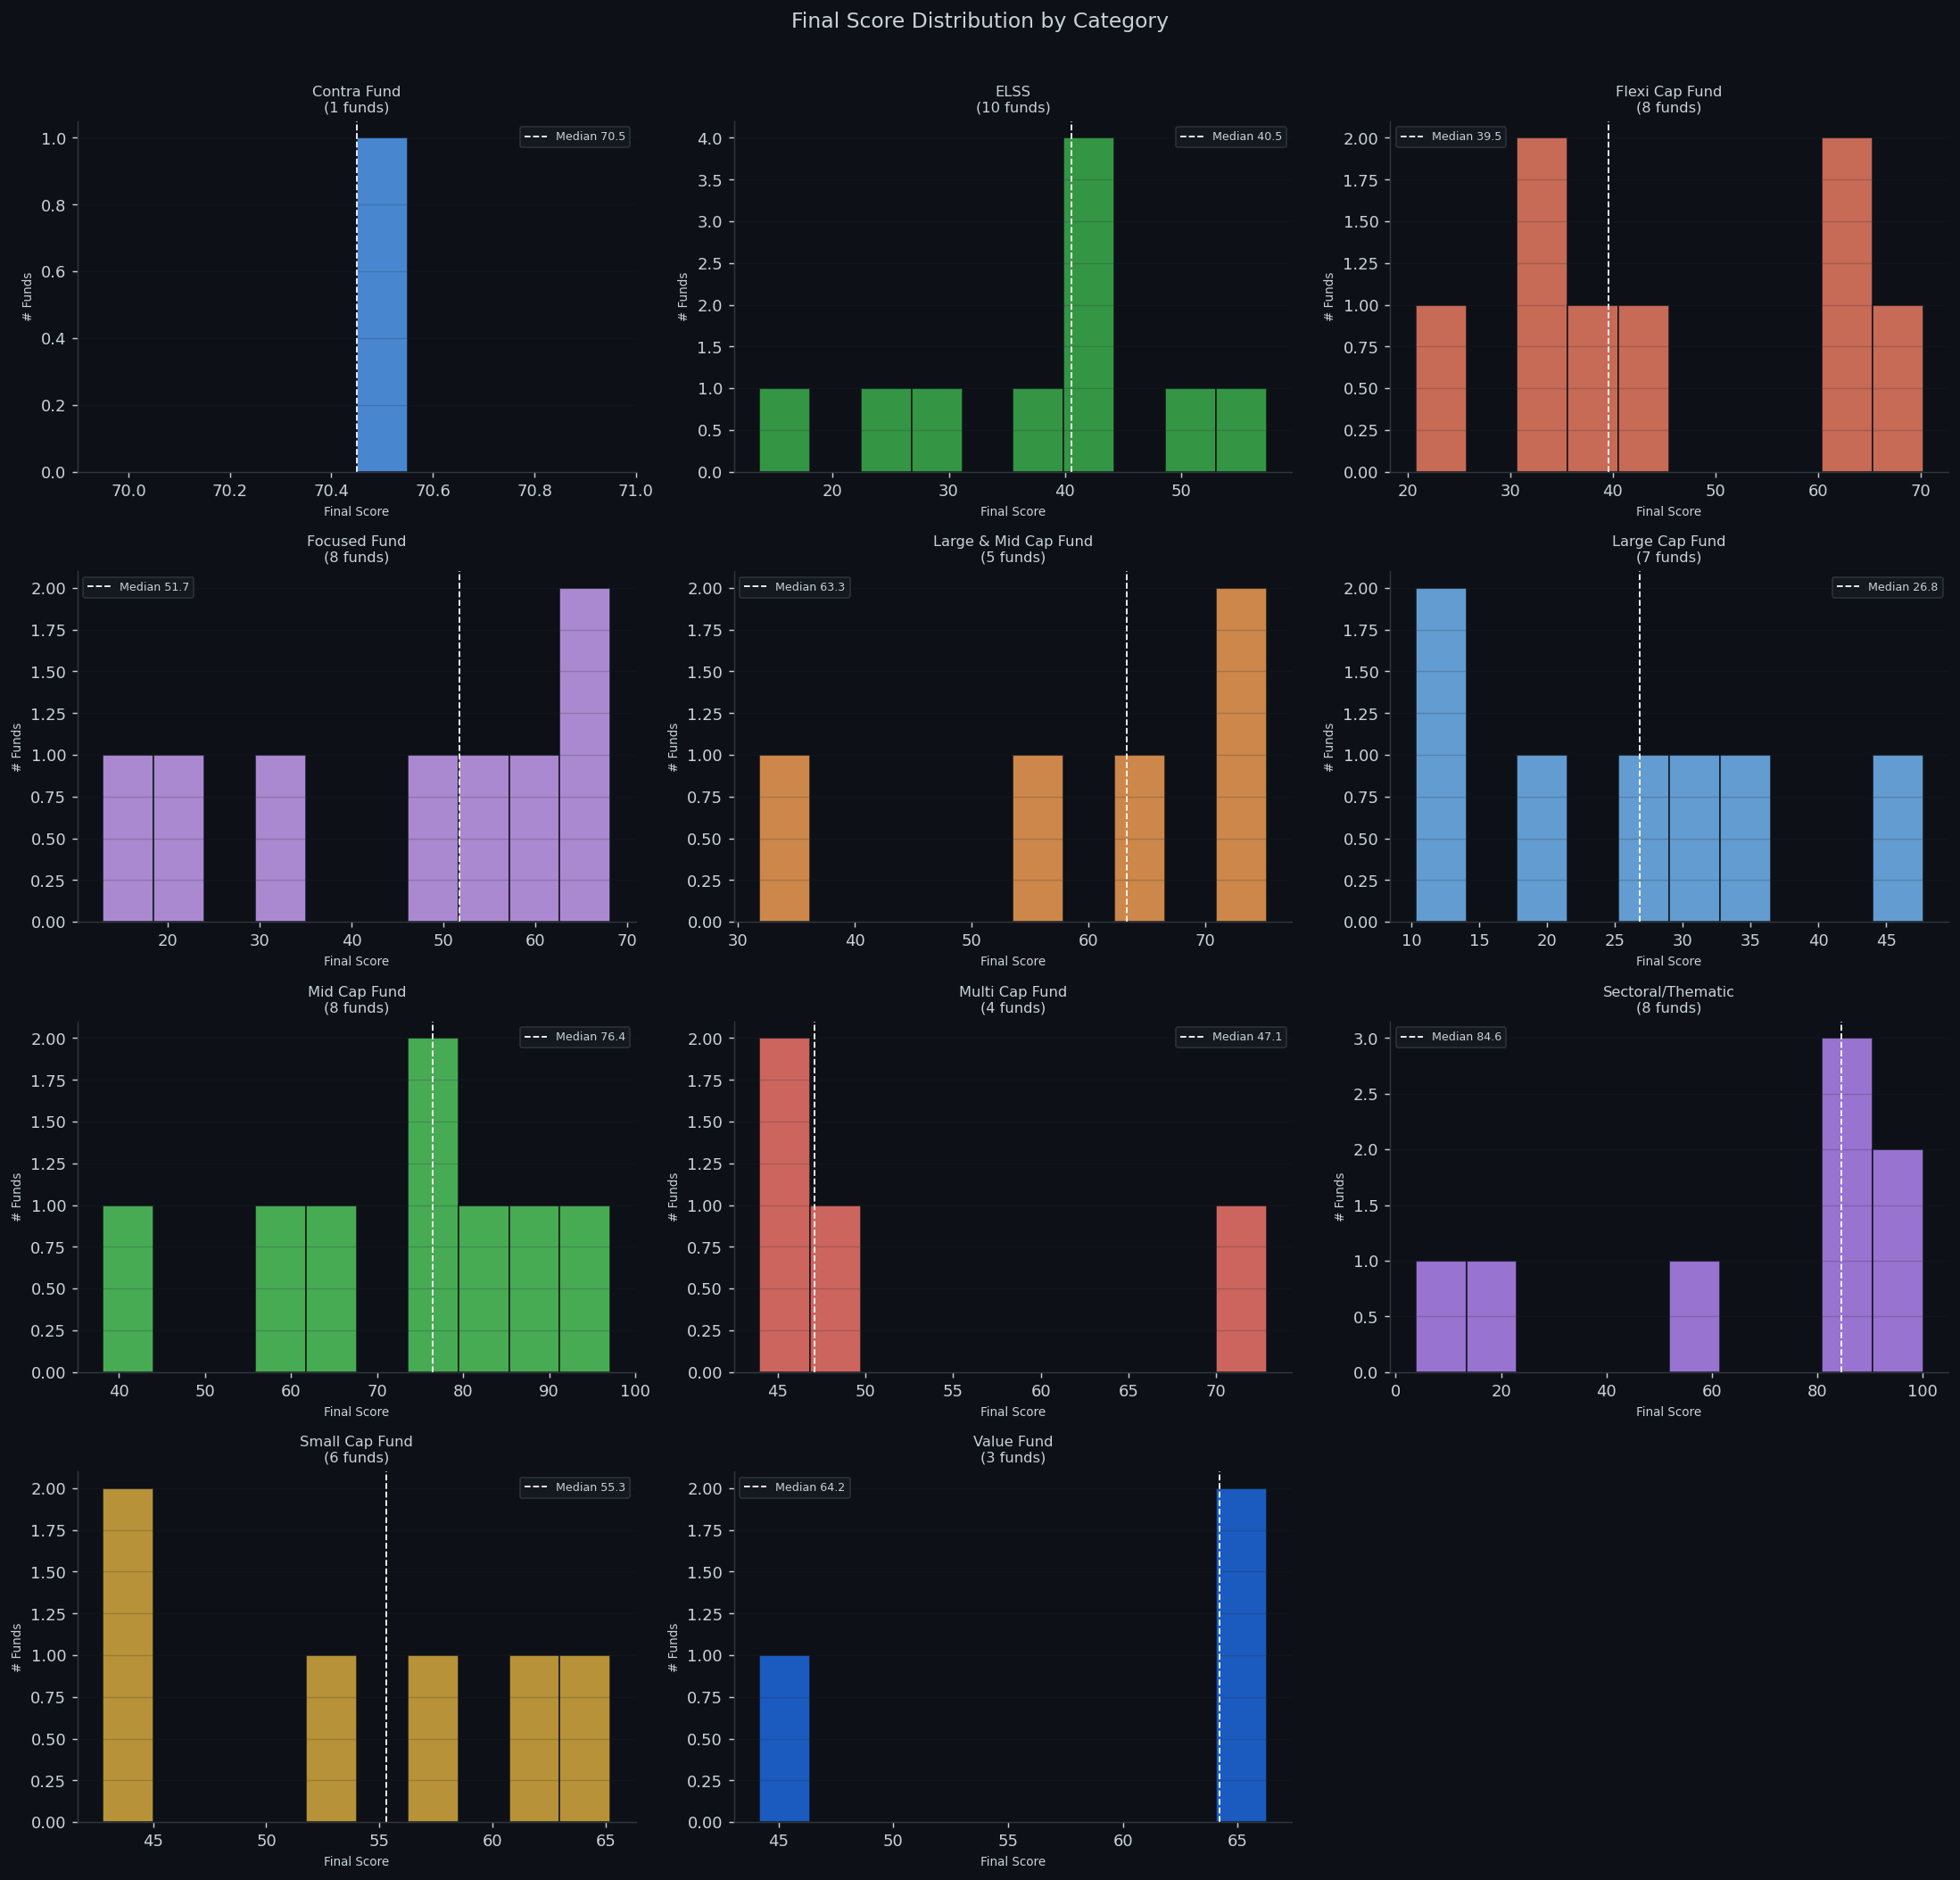

In [7]:
cats = sorted(sc["Category Name"].unique())
n_cats = len(cats)
ncols = 3
nrows = (n_cats + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(17, nrows * 4))
axes_flat = axes.flatten()

for i, cat in enumerate(cats):
    ax = axes_flat[i]
    subset = sc[sc["Category Name"] == cat]["final_score"].dropna()
    color  = cat_colors[cat]

    ax.hist(subset, bins=10, color=color, alpha=0.8, edgecolor="#0d1117")
    ax.axvline(subset.median(), color="white", linewidth=1, linestyle="--",
               label=f"Median {subset.median():.1f}")
    ax.set_title(f"{cat}\n({len(subset)} funds)", fontsize=9, pad=6)
    ax.set_xlabel("Final Score", fontsize=7.5)
    ax.set_ylabel("# Funds", fontsize=7.5)
    ax.legend(fontsize=7)
    ax.grid(axis="y", alpha=0.2)
    for spine in ["top", "right"]: ax.spines[spine].set_visible(False)

# hide empty axes
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle("Final Score Distribution by Category", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [9]:
# ── Top-2 picks per category table ───────────────────────────────────────────
# sort by rank then take first 2 per category (avoids groupby dropping the key col)
top_per_cat = (
    sc.sort_values("rank")
    .groupby("Category Name", group_keys=False)
    .head(2)
    .reset_index(drop=True)
)

out_cat = top_per_cat[[
    "rank", "Short Name", "Category Name", "Crisil Rating", "data_tier",
    "10Y", "5Y", "CV", "score_10Y", "score_5Y", "score_stability", "final_score"
]].copy()
out_cat["data_tier"]     = out_cat["data_tier"].map(TIER_LABEL)
out_cat["Crisil Rating"] = out_cat["Crisil Rating"].astype(int).apply(lambda r: "★" * r)
for c in ["10Y", "5Y"]:
    out_cat[c] = out_cat[c].apply(lambda x: f"{x:.1f}%" if pd.notna(x) else "—")
out_cat["CV"] = out_cat["CV"].apply(lambda x: f"{x:.1f}%" if pd.notna(x) else "—")
for c in ["score_10Y", "score_5Y", "score_stability"]:
    out_cat[c] = out_cat[c].apply(lambda x: f"{x:.0f}" if pd.notna(x) else "—")
out_cat = out_cat.rename(columns={
    "rank": "Rank", "Short Name": "Fund", "Category Name": "Category",
    "Crisil Rating": "Rating", "data_tier": "Data",
    "score_10Y": "S:10Y", "score_5Y": "S:5Y", "score_stability": "S:Stability",
    "final_score": "Final ★",
}).set_index(["Category", "Rank"])
out_cat

,,Fund,Rating,Data,10Y,5Y,CV,S:10Y,S:5Y,S:Stability,Final ★
Category,Rank,,,,,,,,,,
Sectoral/Thematic,1,Bank of India Manufacturing & Infrastructure Fund,★★★★★,Full (10Y+5Y),20.0%,22.3%,9.9%,96,95,96,100.08
Mid Cap Fund,2,Edelweiss Mid Cap Fund,★★★★★,Full (10Y+5Y),20.4%,21.3%,14.2%,98,89,88,97.13
Sectoral/Thematic,3,DSP Natural Resources and New Energy Fund,★★★★★,Full (10Y+5Y),21.0%,21.7%,20.7%,100,93,60,92.00
Mid Cap Fund,4,HDFC Mid Cap Fund,★★★★,Full (10Y+5Y),19.6%,21.4%,14.4%,93,91,87,91.01
Large & Mid Cap Fund,10,Bandhan Large & Mid Cap Fund,★★★★★,Full (10Y+5Y),17.8%,19.0%,20.5%,76,74,62,75.25
Multi Cap Fund,12,Kotak Multicap Fund,★★★★★,New (3Y),—,—,22.1%,—,—,54,72.88
Large & Mid Cap Fund,13,ICICI Prudential Large & Mid Cap Fund- Direct ...,★★★★★,Full (10Y+5Y),17.3%,19.3%,24.2%,71,80,47,71.36
Contra Fund,14,Kotak Contra Fund,★★★★,Full (10Y+5Y),18.0%,17.0%,15.8%,80,53,79,70.45
Flexi Cap Fund,15,HDFC Flexi Cap Fund,★★★★★,Full (10Y+5Y),18.0%,19.0%,26.7%,78,75,37,70.24


## 6. Results by Crisil Rating

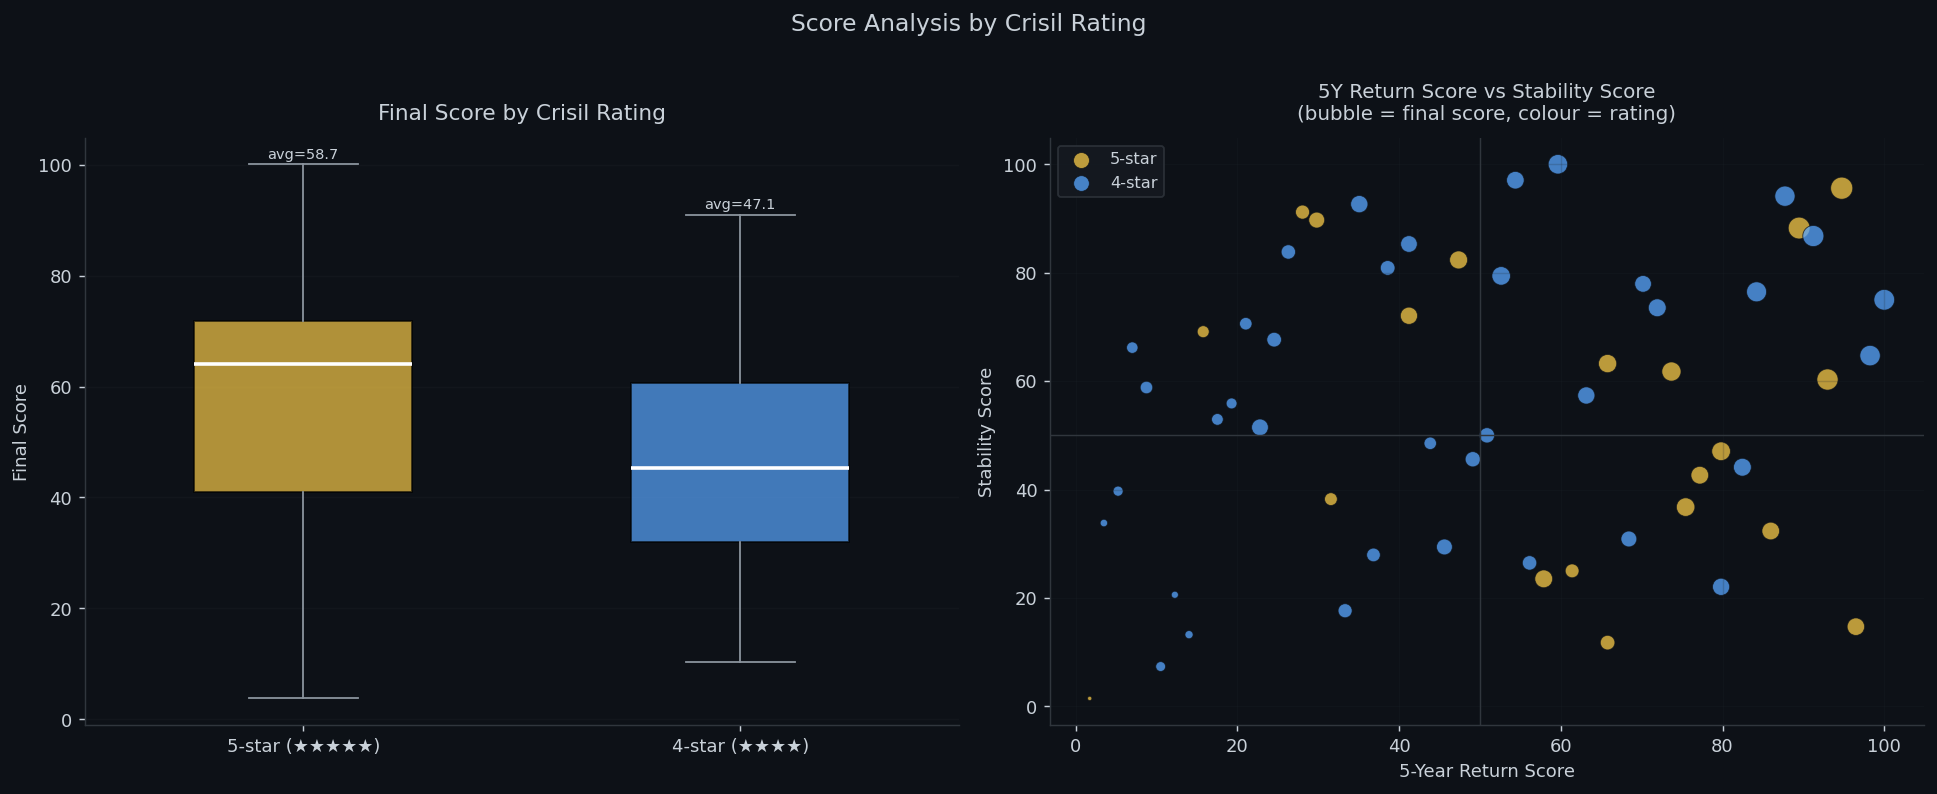

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Left: box plot of final scores by rating ─────────────────────────────────
rating_groups = [sc[sc["Crisil Rating"] == r]["final_score"].dropna() for r in [5, 4]]
bp = axes[0].boxplot(
    rating_groups,
    labels=["5-star (★★★★★)", "4-star (★★★★)"],
    patch_artist=True,
    widths=0.5,
    medianprops={"color": "white", "linewidth": 2},
    whiskerprops={"color": "#8b949e"},
    capprops={"color": "#8b949e"},
    flierprops={"marker": "o", "color": "#8b949e", "markersize": 4},
)
for patch, color in zip(bp["boxes"], ["#f7c948", "#58a6ff"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[0].set_ylabel("Final Score", fontsize=10)
axes[0].set_title("Final Score by Crisil Rating", fontsize=12, pad=10)
axes[0].grid(axis="y", alpha=0.25)
for spine in ["top", "right"]: axes[0].spines[spine].set_visible(False)

# stats annotation
for x, grp in enumerate(rating_groups, 1):
    axes[0].text(x, grp.max() + 1, f"avg={grp.mean():.1f}", ha="center",
                 fontsize=8, color="#c9d1d9")

# ── Right: scatter component scores (5Y vs stability) coloured by rating ──────
for r, col, lbl in [(5, "#f7c948", "5-star"), (4, "#58a6ff", "4-star")]:
    sub = sc[sc["Crisil Rating"] == r]
    axes[1].scatter(
        sub["score_5Y"], sub["score_stability"],
        c=col, s=sub["final_score"] * 1.5,
        alpha=0.75, edgecolors="#0d1117", linewidth=0.5, label=lbl,
    )

axes[1].set_xlabel("5-Year Return Score", fontsize=10)
axes[1].set_ylabel("Stability Score", fontsize=10)
axes[1].set_title("5Y Return Score vs Stability Score\n(bubble = final score, colour = rating)",
                  fontsize=11, pad=10)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.2)
axes[1].axvline(50, color="#30363d", linewidth=0.8)
axes[1].axhline(50, color="#30363d", linewidth=0.8)
for spine in ["top", "right"]: axes[1].spines[spine].set_visible(False)

plt.suptitle("Score Analysis by Crisil Rating", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 7. Radar Charts for Top Picks

Radar (spider) charts for the **top 8 funds** across three axes:
- 10Y Return Score (or 5Y/3Y if unavailable)
- 5Y Return Score (or 3Y if unavailable)
- Stability Score

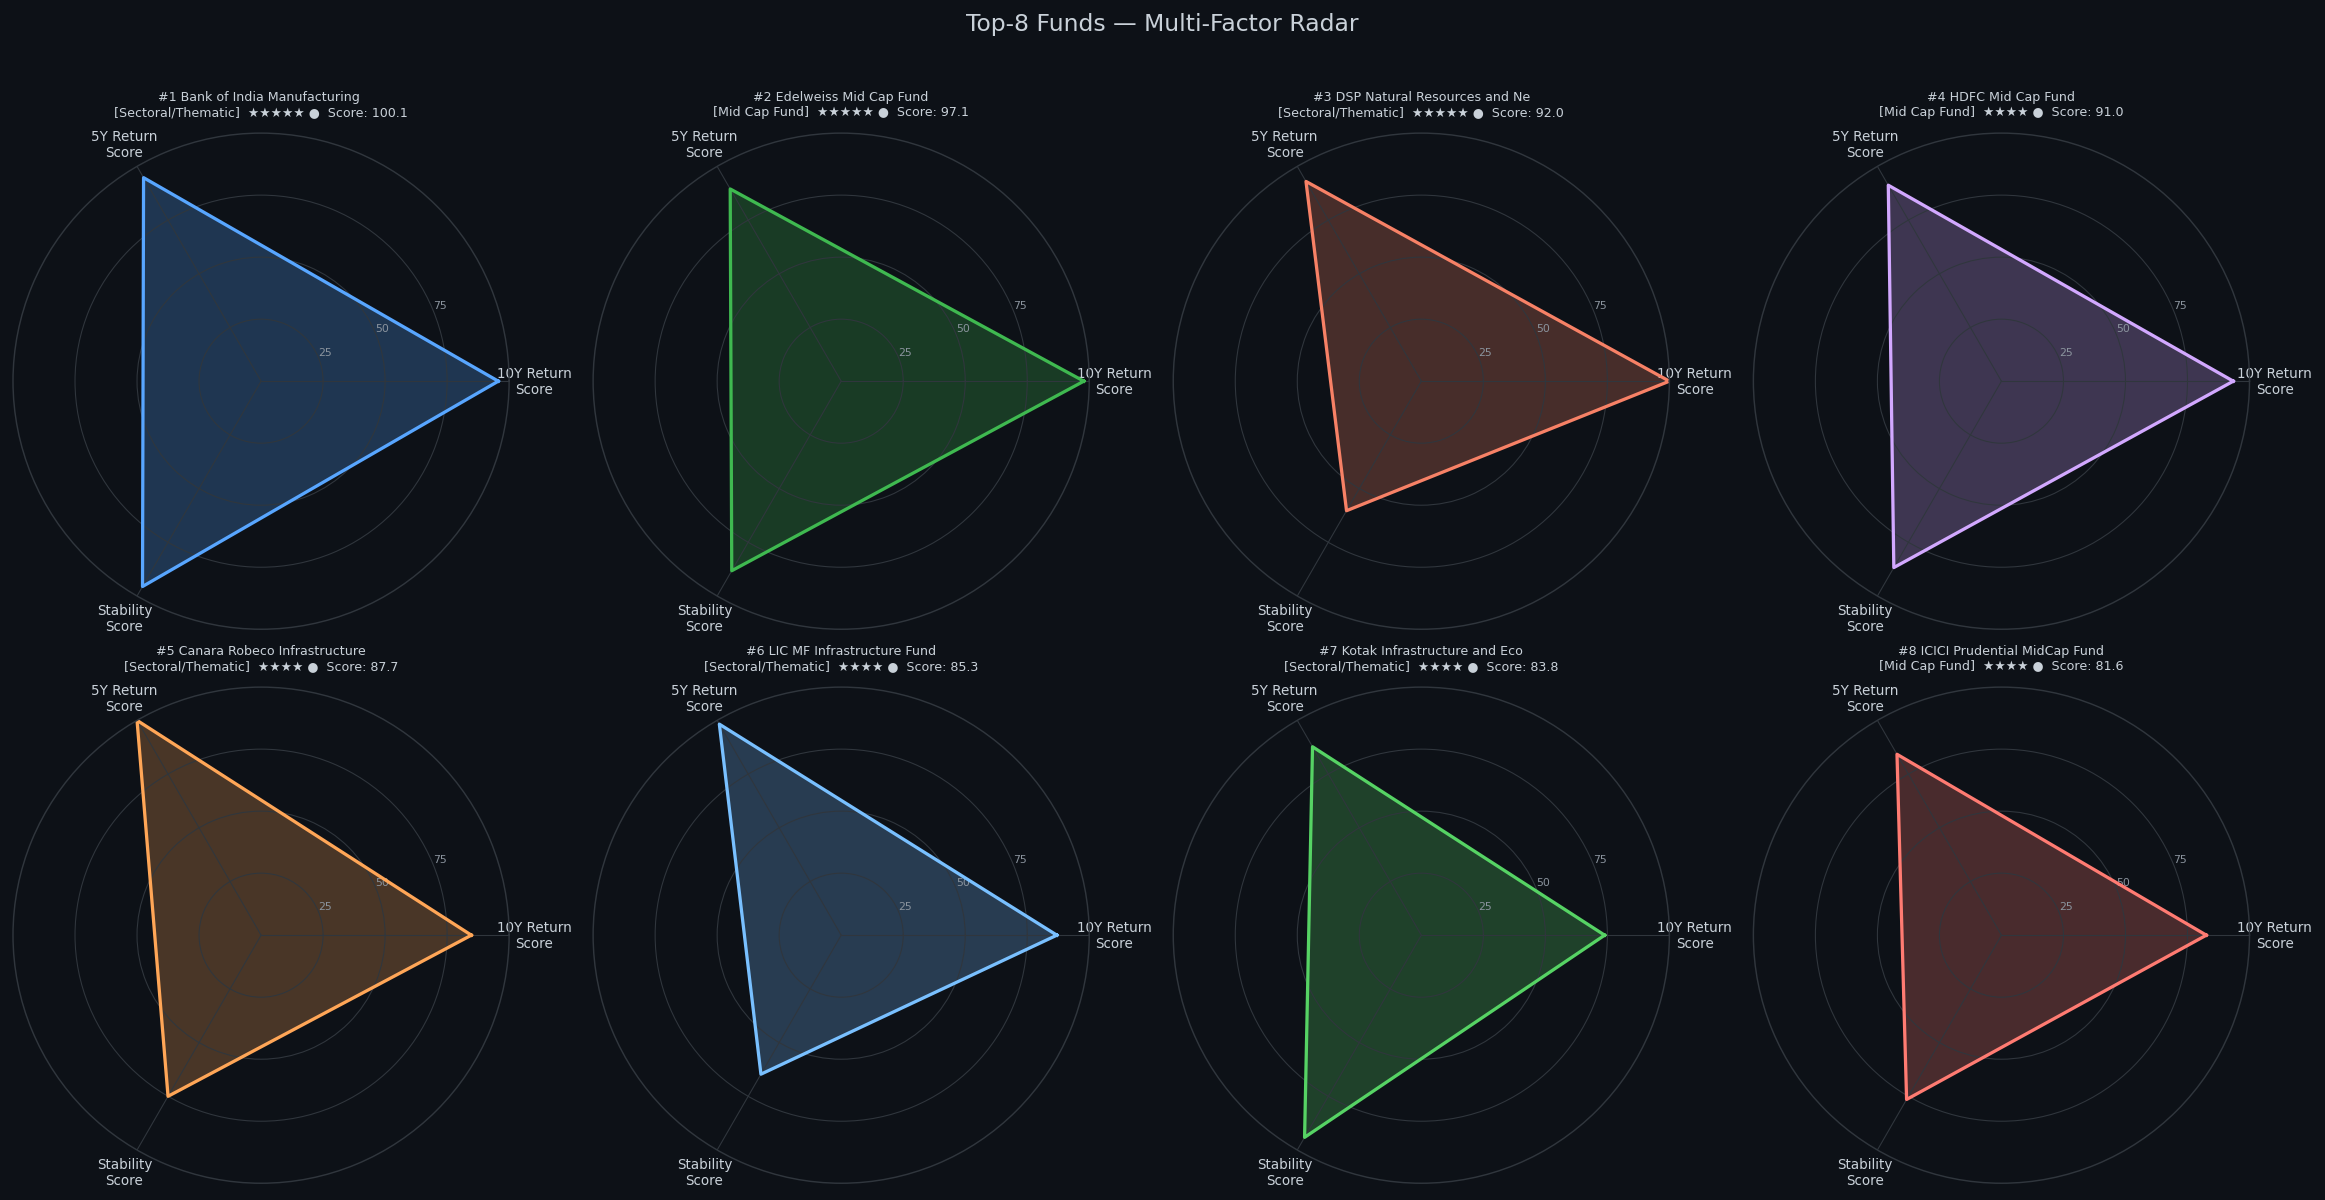

In [11]:
TOP_N = 8
top_funds = sc.head(TOP_N).copy()

# axes: use best available return score for long-horizon axis
top_funds["radar_10Y"]       = top_funds["score_10Y"].fillna(top_funds["score_5Y"]).fillna(top_funds["score_3Y"])
top_funds["radar_5Y"]        = top_funds["score_5Y"].fillna(top_funds["score_3Y"])
top_funds["radar_stability"] = top_funds["score_stability"]

RADAR_LABELS = ["10Y Return\nScore", "5Y Return\nScore", "Stability\nScore"]
N_AXES = len(RADAR_LABELS)
angles = np.linspace(0, 2 * np.pi, N_AXES, endpoint=False).tolist()
angles += angles[:1]   # close the polygon

ncols, nrows = 4, 2
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 9),
                         subplot_kw={"polar": True})
axes_flat = axes.flatten()

for i, (_, row) in enumerate(top_funds.iterrows()):
    ax     = axes_flat[i]
    color  = PALETTE[i % len(PALETTE)]
    values = [
        row["radar_10Y"],
        row["radar_5Y"],
        row["radar_stability"],
    ]
    values += values[:1]

    ax.plot(angles, values, color=color, linewidth=1.8)
    ax.fill(angles, values, color=color, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(RADAR_LABELS, fontsize=7.5, color="#c9d1d9")
    ax.set_ylim(0, 100)
    ax.set_yticks([25, 50, 75])
    ax.set_yticklabels(["25", "50", "75"], fontsize=6, color="#8b949e")
    ax.grid(color="#30363d", linewidth=0.6)
    ax.set_facecolor("#0d1117")
    ax.spines["polar"].set_color("#30363d")

    tier = row["data_tier"]
    tier_sym = {"A": "●", "B": "◑", "C": "○"}[tier]
    stars = "★" * int(row["Crisil Rating"])
    ax.set_title(
        f"#{int(row['rank'])} {row['Short Name'][:28]}\n"
        f"[{row['Category Name']}]  {stars} {tier_sym}  Score: {row['final_score']:.1f}",
        fontsize=7, pad=10, color="#c9d1d9"
    )

# hide unused axes if any
for j in range(TOP_N, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle("Top-8 Funds — Multi-Factor Radar", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 8. Investment Decision Summary

Bring together:
- Overall top 10 picks  
- Best pick per category (diversified portfolio view)  
- Factor contribution breakdown for the top picks

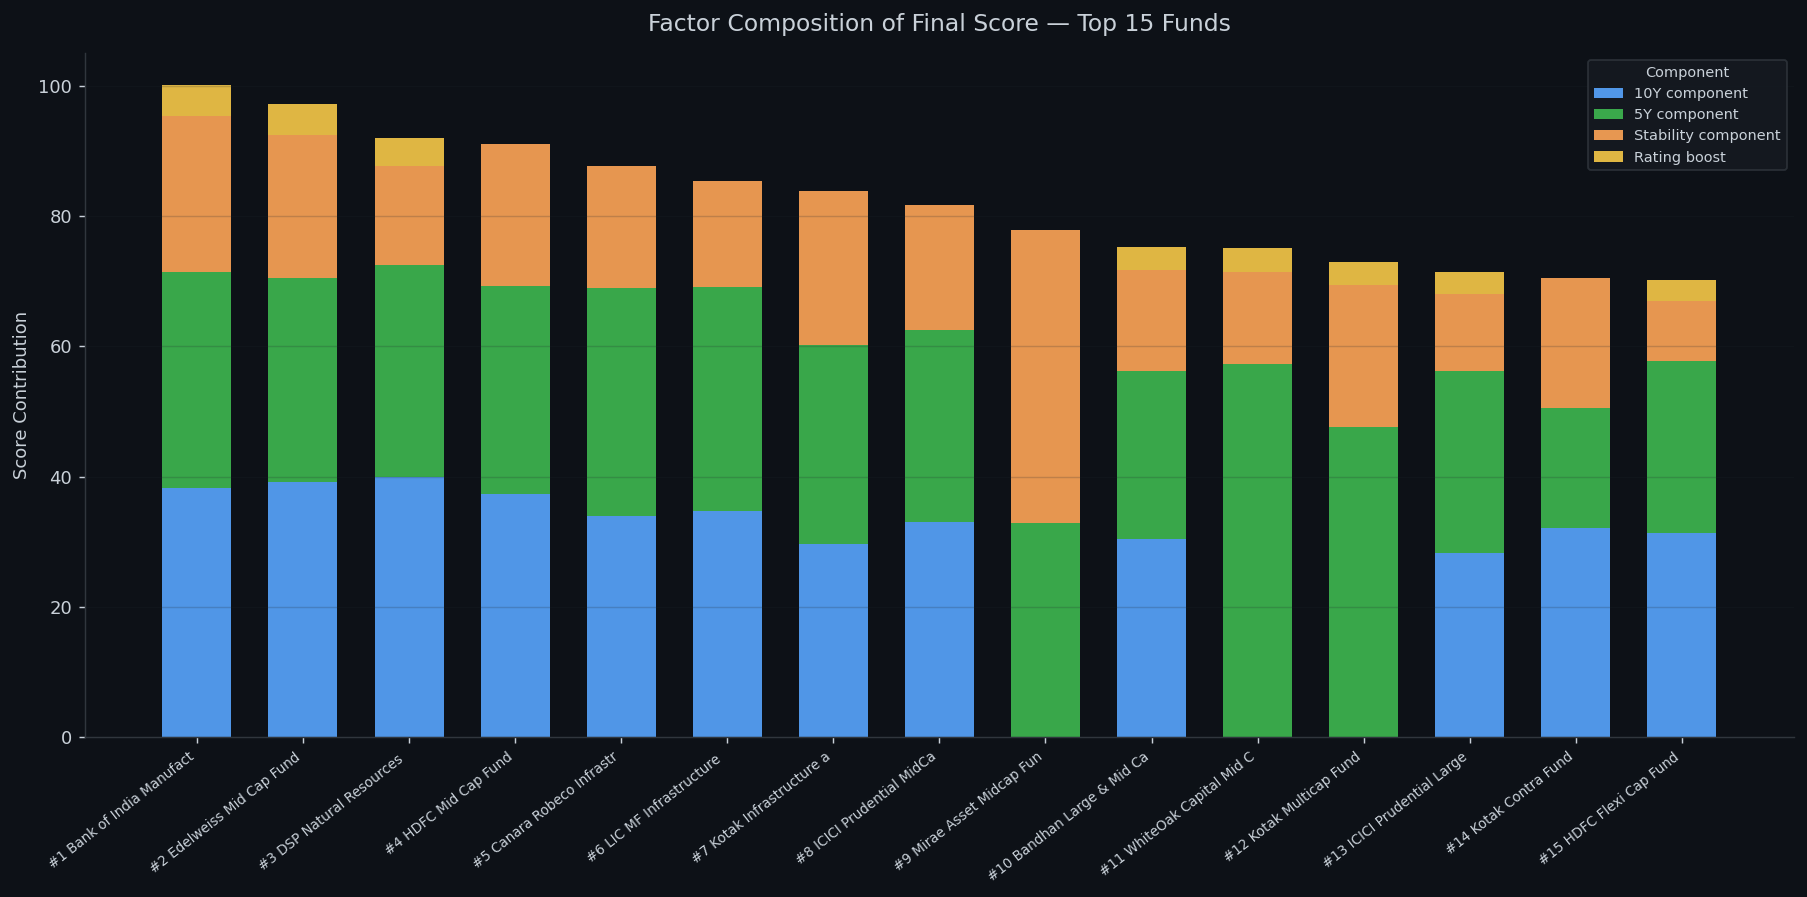

In [12]:
# ── Stacked bar: factor contribution for top-15 ──────────────────────────────
top15 = sc.head(15).copy()

# effective weighted contributions per tier
def factor_contributions(row):
    t = row["data_tier"]
    if t == "A":
        c10  = 0.40 * (row["score_10Y"]       or 0)
        c5   = 0.35 * (row["score_5Y"]        or 0)
        cstb = 0.25 * (row["score_stability"] or 0)
    elif t == "B":
        c10  = 0.0
        c5   = 0.55 * (row["score_5Y"]        or 0)
        cstb = 0.45 * (row["score_stability"] or 0)
    else:
        c10  = 0.0
        c5   = 0.60 * (row["score_3Y"]        or 0)
        cstb = 0.40 * (row["score_stability"] or 0)
    rating_boost = row["composite_score"] * (row["rating_mult"] - 1)
    return pd.Series({"10Y component": c10, "5Y component": c5,
                      "Stability component": cstb, "Rating boost": rating_boost})

contrib = top15.apply(factor_contributions, axis=1)
labels  = [f"#{r} {n[:22]}" for r, n in zip(top15["rank"], top15["Short Name"])]

fig, ax = plt.subplots(figsize=(14, 7))
bottom = np.zeros(len(top15))
comp_colors = ["#58a6ff", "#3fb950", "#ffa657", "#f7c948"]

for col, color in zip(contrib.columns, comp_colors):
    ax.bar(range(len(top15)), contrib[col], bottom=bottom,
           label=col, color=color, width=0.65, alpha=0.9)
    bottom += contrib[col].values

ax.set_xticks(range(len(top15)))
ax.set_xticklabels(labels, rotation=38, ha="right", fontsize=7.5)
ax.set_ylabel("Score Contribution", fontsize=10)
ax.set_title("Factor Composition of Final Score — Top 15 Funds", fontsize=13, pad=12)
ax.legend(title="Component", fontsize=8, title_fontsize=8)
ax.grid(axis="y", alpha=0.2)
for spine in ["top", "right"]: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

In [14]:
# ── Best one pick per category (diversified portfolio view) ──────────────────
best_per_cat = (
    sc.sort_values("rank")
    .groupby("Category Name", group_keys=False)
    .head(1)
    .sort_values("final_score", ascending=False)
    .reset_index(drop=True)
)

print("=" * 80)
print("  DIVERSIFIED PORTFOLIO — BEST FUND PER CATEGORY")
print("=" * 80)
for _, row in best_per_cat.iterrows():
    tier_sym = {"A": "●", "B": "◑", "C": "○"}[row["data_tier"]]
    stars    = "★" * int(row["Crisil Rating"])
    ry10 = f"{row['10Y']:.1f}%" if pd.notna(row['10Y']) else "  n/a"
    ry5  = f"{row['5Y']:.1f}%"  if pd.notna(row['5Y'])  else "  n/a"
    print(f"[Rank #{int(row['rank']):>2}] {stars} {tier_sym}  Score: {row['final_score']:5.1f}"
          f"  | 10Y: {ry10:>6}  5Y: {ry5:>6}  CV: {row['CV']:.1f}%"
          f"  | {row['Category Name']}")
    print(f"         {row['Short Name']}")
    print()

print("=" * 80)
print("  OVERALL TOP 10")
print("=" * 80)
for _, row in sc.head(10).iterrows():
    tier_sym = {"A": "●", "B": "◑", "C": "○"}[row["data_tier"]]
    stars    = "★" * int(row["Crisil Rating"])
    ry10 = f"{row['10Y']:.1f}%" if pd.notna(row['10Y']) else "  n/a"
    ry5  = f"{row['5Y']:.1f}%"  if pd.notna(row['5Y'])  else "  n/a"
    print(f"[Rank #{int(row['rank']):>2}] {stars} {tier_sym}  Score: {row['final_score']:5.1f}"
          f"  | 10Y: {ry10:>6}  5Y: {ry5:>6}  CV: {row['CV']:.1f}%"
          f"  | {row['Category Name']}")
    print(f"         {row['Short Name']}")
    print()

  DIVERSIFIED PORTFOLIO — BEST FUND PER CATEGORY
[Rank # 1] ★★★★★ ●  Score: 100.1  | 10Y:  20.0%  5Y:  22.3%  CV: 9.9%  | Sectoral/Thematic
         Bank of India Manufacturing & Infrastructure Fund

[Rank # 2] ★★★★★ ●  Score:  97.1  | 10Y:  20.4%  5Y:  21.3%  CV: 14.2%  | Mid Cap Fund
         Edelweiss Mid Cap Fund

[Rank #10] ★★★★★ ●  Score:  75.2  | 10Y:  17.8%  5Y:  19.0%  CV: 20.5%  | Large & Mid Cap Fund
         Bandhan Large & Mid Cap Fund

[Rank #12] ★★★★★ ○  Score:  72.9  | 10Y:    n/a  5Y:    n/a  CV: 22.1%  | Multi Cap Fund
         Kotak Multicap Fund

[Rank #14] ★★★★ ●  Score:  70.5  | 10Y:  18.0%  5Y:  17.0%  CV: 15.8%  | Contra Fund
         Kotak Contra Fund

[Rank #15] ★★★★★ ●  Score:  70.2  | 10Y:  18.0%  5Y:  19.0%  CV: 26.7%  | Flexi Cap Fund
         HDFC Flexi Cap Fund

[Rank #16] ★★★★★ ●  Score:  68.2  | 10Y:  17.0%  5Y:  18.2%  CV: 20.5%  | Focused Fund
         ICICI Prudential Focused Equity Fund

[Rank #17] ★★★★★ ◑  Score:  66.3  | 10Y:    n/a  5Y:  16.1%  